# Machine Learning Internship - Week 1

## Assignments and Mini Project

ASSIGNMENT 1 : LOAD AND SUMMARIZE DATASET

In [30]:
# Assignment 1: Load and Summarize Dataset

import pandas as pd

# Load the Titanic dataset

df = pd.read_csv("/home/rossane/assignment1_pandas/Titanic-Dataset.csv")

# Display the first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
### Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [32]:
### Statistical Summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


ASSIGNMENT 2 : HANDLING MISSING DATA

In [33]:
# Assignment 2: Handling Missing Data

# Check missing values before imputation

print("Missing Age values before imputation:")
print(df["Age"].isnull().sum())

# Mean imputation

age_mean = df["Age"].mean()
df["Age"] = df["Age"].fillna(age_mean)

# Check missing values after imputation

print("\nMissing Age values after mean imputation:")
print(df["Age"].isnull().sum())

Missing Age values before imputation:
177

Missing Age values after mean imputation:
0


Assignment 3: Categorical Variable Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding for Sex

label_encoder = LabelEncoder()
df["Sex_Encoded"] = label_encoder.fit_transform(df["Sex"])

# One-Hot Encoding for Embarked

one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

embarked_encoded = one_hot_encoder.fit_transform(df[["Embarked"]])

# Convert encoded data into DataFrame

embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=one_hot_encoder.get_feature_names_out(["Embarked"]),
    index=df.index
)

# Add encoded columns to the dataset

df = pd.concat([df, embarked_df], axis=1)

# Display the result

df[["Sex", "Sex_Encoded", "Embarked"] + list(embarked_df.columns)].head()

,Sex,Sex_Encoded,Embarked,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,male,1,S,0.0,0.0,1.0,0.0
1,female,0,C,1.0,0.0,0.0,0.0
2,female,0,S,0.0,0.0,1.0,0.0
3,female,0,S,0.0,0.0,1.0,0.0
4,male,1,S,0.0,0.0,1.0,0.0


# Mini Project 1: Titanic Survival Prediction — Data Cleaning

## Project Objective

The objective of this project is to clean the Titanic dataset,
handle missing values, encode categorical variables, visualize
the Age distribution, and save the cleaned dataset as a new CSV file.

## 1. Handling Missing Data

In [1]:
# Import pandas library

import pandas as pd

# Load the original Titanic dataset

df = pd.read_csv("/home/rossane/assignment1_pandas/Titanic-Dataset.csv")

# Display confirmation message

print("\nDataset loaded successfully!")

# Display the shape of the dataset

print("\nShape of dataset:", df.shape)

# Display the first five rows

print("\n")
df.head()


Dataset loaded successfully!

Shape of dataset: (891, 12)




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Check missing values in each column

print("Missing values before cleaning:")

# Display missing value count

print("\n")
print(df.isnull().sum())

Missing values before cleaning:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Fill missing Age values with the mean Age

print("\n")
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing Embarked values with the most frequent value

print("\n")
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it contains many missing values

print("\n")
df = df.drop(columns=["Cabin"])

# Display missing values after cleaning

print("\n")
print("Missing values after cleaning:")
print(df.isnull().sum())









Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 2. Encoding Categorical Variables

In [4]:
# Import encoding techniques

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Create LabelEncoder

label_encoder = LabelEncoder()

# Encode the Sex column

df["Sex_Encoded"] = label_encoder.fit_transform(df["Sex"])

# Create OneHotEncoder

one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

# Encode the Embarked column

embarked_encoded = one_hot_encoder.fit_transform(df[["Embarked"]])

# Convert encoded values into a DataFrame

embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=one_hot_encoder.get_feature_names_out(["Embarked"]),
    index=df.index
)

# Add encoded columns to the dataset

df = pd.concat([df, embarked_df], axis=1)

# Display confirmation

print("Encoding completed successfully!")

# Display first five rows

df.head()

Encoding completed successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Sex_Encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0.0,0.0,1.0


## 3. Age Distribution Visualization

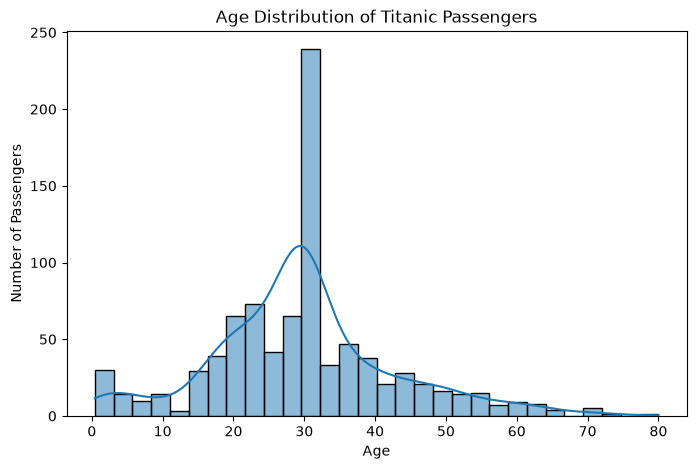

In [5]:
# Import Matplotlib and Seaborn

import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size

plt.figure(figsize=(8, 5))

# Create Age distribution histogram

sns.histplot(df["Age"], bins=30, kde=True)

# Add graph title

plt.title("Age Distribution of Titanic Passengers")

# Add x-axis label

plt.xlabel("Age")

# Add y-axis label

plt.ylabel("Number of Passengers")

# Display the graph

plt.show()

## 4. Save Cleaned Dataset

In [6]:
# Set the path for the new cleaned CSV file

cleaned_file = "/home/rossane/assignment1_pandas/titanic_cleaned.csv"

# Save the cleaned dataset as a new CSV file

df.to_csv(cleaned_file, index=False)

# Display confirmation

print("Cleaned dataset saved successfully!")

# Display file location

print("File:", cleaned_file)

Cleaned dataset saved successfully!
File: /home/rossane/assignment1_pandas/titanic_cleaned.csv


## Final Result

The Titanic dataset was successfully cleaned, missing values were handled,
the Sex and Embarked columns were encoded, the Age distribution was
visualized, and the cleaned dataset was saved as a new CSV file.

In [7]:
# Display the first five rows of the final cleaned dataset

df.head()

# Display the final shape of the dataset

print("\n")
print("Final shape of dataset:", df.shape)



Final shape of dataset: (891, 15)
